# MolmoWeb Inference Demo

This notebook demonstrates the `MolmoWeb` inference client through a
single end-to-end scenario: discovering a product, getting its details,
then price-comparing it across multiple stores in parallel.

1. **Single query** — find a trending product on a site
2. **Follow-up query** — get the exact product name and model number
3. **Batch (parallel) queries** — price-compare that product across 5 retailers at once

In [11]:
from inference import MolmoWeb


client = MolmoWeb(
    local=True,
    headless=True,
)

## 1. Discover a Product

First, ask the agent to find something worth buying.

In [12]:
query = "Go to allenai.org and open the top project on the homepage. "
traj = client.run(query=query, max_steps=10)

[03:11:20] Step  1: goto(url='https://allenai.org')
[03:11:27] Step  2: mouse_click(x=640.0, y=270.0, button='left')
[03:11:31] Step  3: send_msg_to_user(text='[ANSWER] Done')


### Inspect a step in detail

In [13]:
step = traj.steps[-1]

if step.prediction:
    print("Thought:", step.prediction.thought)
    print("Action:", step.prediction.to_str())

Thought: The goal was to navigate to allenai.org and open the top project on the homepage. I have already navigated to the site and clicked on 'MolmoBot', which is the top featured project. The task is now complete.
Action: send_msg_to_user(text='[ANSWER] Done')


### Display the last screenshot

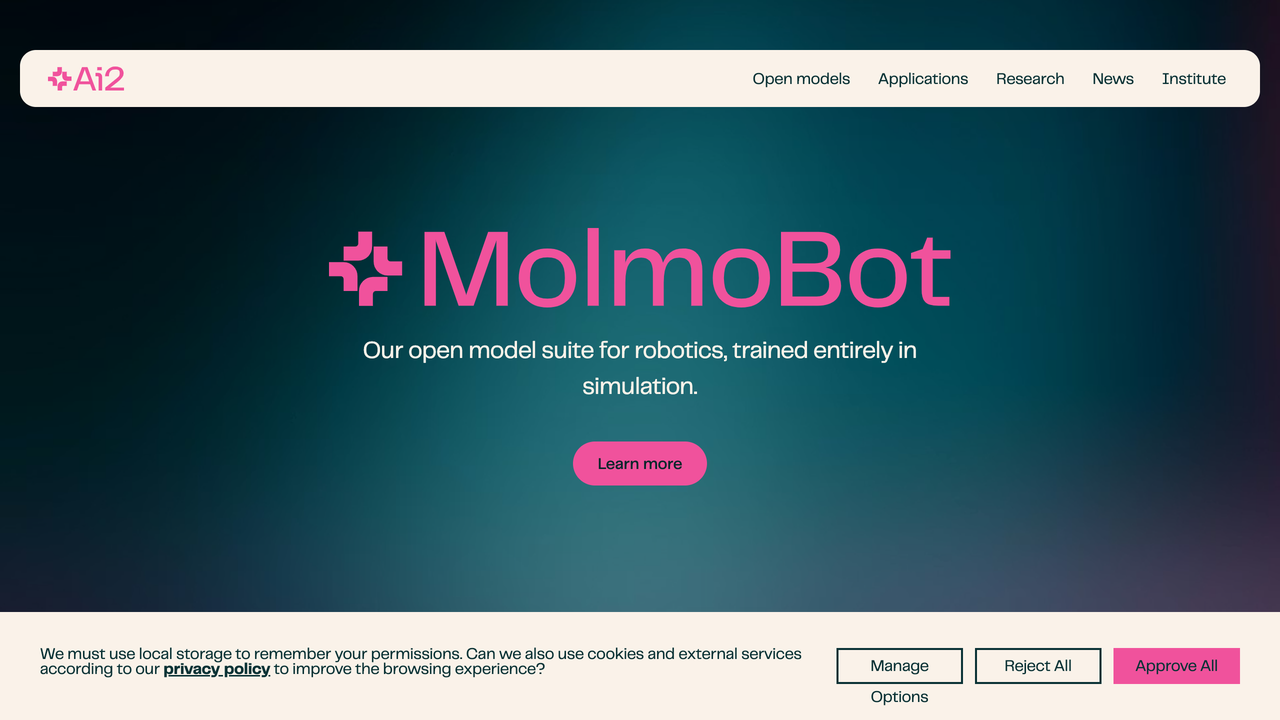

In [14]:
last_state = traj.steps[-1].state
if last_state:
    display(last_state.img)

### Save trajectory as HTML

In [15]:
html_path = traj.save_html(query=query)
print(f"Saved to: {html_path}")

Saved to: inference/htmls/trajectory.html


## 2. Get the Details

With `keep_alive=True`, the browser session persists between calls.
The agent is still on the product page — ask it for the exact details
we need for the price comparison.

In [16]:
followup_query = "Find the author list of MolmoBot in the tech report."
traj2 = client.continue_run(query=followup_query, max_steps=10)

[03:11:52] Step  1: mouse_click(x=643.8, y=465.8, button='left')
[03:11:58] Step  2: mouse_click(x=632.3, y=409.7, button='left')
[03:12:05] Step  3: send_msg_to_user(text='[ANSWER] Abhay Deshpande, Maya Guru, Rose Hendrix, Snehal Jaohri, Ainaz Eftekhhar, Rohun Tripathi, Max Argus, Jordi Salvador, Haoquan Fang, Matthew Wallingford, Wilbert Pumacay, Yejin Kim, Quinn Pfieffer, Ying-Chun Lee, Piper Wolters, Omar Rayyan, Mingtong Zhang, Jiafei Duan, Karen Farley, Wilson Han, Eli Vandenbilt, Dietter Fox, Ali Farhadi, Georgia Chalvatzi, Dhruv Shah, Ranjay Krishna')


Thought: The goal is to find the author list for MolmoBot. I have navigated to the arXiv page for the technical report 'MolmoBot: Large-Scale Simulation Enables Zero-Shot Manipulation'. The authors are clearly listed on this page. I will now provide the author list to the user.
Action: send_msg_to_user(text='[ANSWER] Abhay Deshpande, Maya Guru, Rose Hendrix, Snehal Jaohri, Ainaz Eftekhhar, Rohun Tripathi, Max Argus, Jordi Salvador, Haoquan Fang, Matthew Wallingford, Wilbert Pumacay, Yejin Kim, Quinn Pfieffer, Ying-Chun Lee, Piper Wolters, Omar Rayyan, Mingtong Zhang, Jiafei Duan, Karen Farley, Wilson Han, Eli Vandenbilt, Dietter Fox, Ali Farhadi, Georgia Chalvatzi, Dhruv Shah, Ranjay Krishna')


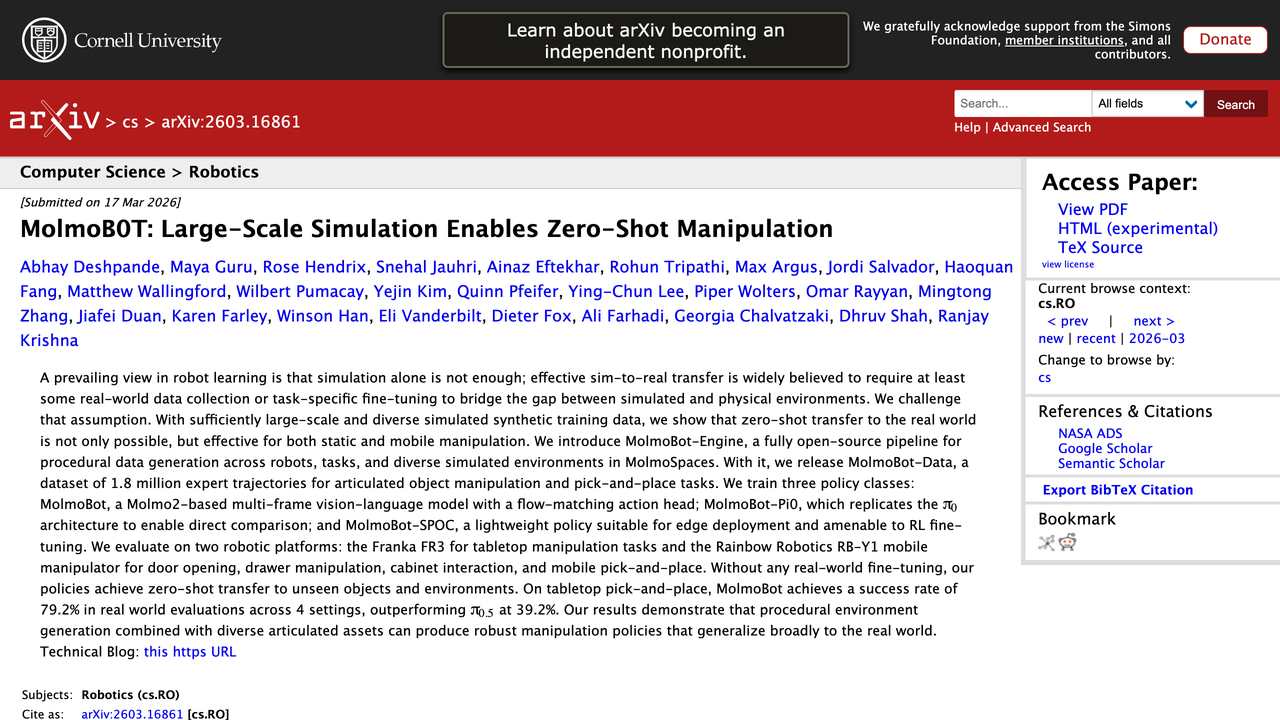

In [17]:
last_step = traj2.steps[-1]
if last_step.prediction:
    print("Thought:", last_step.prediction.thought)
    print("Action:", last_step.prediction.to_str())

if last_step.state:
    display(last_step.state.img)

In [18]:
html_path2 = traj2.save_html(output_path="inference/htmls/followup.html", query=followup_query)
print(f"Saved to: {html_path2}")

Saved to: inference/htmls/followup.html


## 3. Price Compare in Parallel

Now take the product from above and check its price across 5 retailers
at once. Sequentially this would take 5x as long — batch runs them all
simultaneously.

In [ ]:
AUTHORS = last_step.prediction.action.msg.replace("[ANSWER] ", "").split(", ")

queries = [f"Go to {author}'s personal website and search for their affiliation and research interests. " for author in AUTHORS]

trajectories = client.run_batch(
    queries=queries,
    max_steps=10,
    max_workers=3,
)

Batch:   0%|          | 0/26 [00:00<?, ?it/s]

  [2] "Go to Rose Hendrix's personal website and search for their a..." (8 steps)
  [1] "Go to Maya Guru's personal website and search for their affi..." (10 steps)
  [0] "Go to Abhay Deshpande's personal website and search for thei..." (10 steps)
  [3] "Go to Snehal Jaohri's personal website and search for their ..." (10 steps)
  [5] "Go to Rohun Tripathi's personal website and search for their..." (10 steps)
  [4] "Go to Ainaz Eftekhhar's personal website and search for thei..." (10 steps)
  [7] "Go to Jordi Salvador's personal website and search for their..." (10 steps)
  [6] "Go to Max Argus's personal website and search for their affi..." (10 steps)
  [8] "Go to Haoquan Fang's personal website and search for their a..." (10 steps)
  [10] "Go to Wilbert Pumacay's personal website and search for thei..." (10 steps)
  [9] "Go to Matthew Wallingford's personal website and search for ..." (10 steps)
  [11] "Go to Yejin Kim's personal website and search for their affi..." (10 steps)
  [

## Cleanup

In [1]:
client.close()

NameError: name 'client' is not defined